# Exercise 2: Master vs Single - Performance Analysis

## Run the benchmark first:
```bash
gcc benchmark.c -O2 -fopenmp -o benchmark
./benchmark > results.csv
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Data from CSV

In [2]:
# Load data from CSV
df = pd.read_csv('results.csv')

# Separate serial and parallel data
serial_data = df[df['threads'] == 0].iloc[0]
parallel_data = df[df['threads'] > 0].copy()

print("Serial baseline:")
print(f"  Total time: {serial_data['total_time']:.6f} s")
print(f"  Init time: {serial_data['init_time']:.6f} s")
print(f"  Sum time: {serial_data['sum_time']:.6f} s")
print("\nParallel results:")
print(parallel_data[['threads', 'total_time', 'speedup', 'efficiency']])

Serial baseline:
  Total time: 0.002511 s
  Init time: 0.001614 s
  Sum time: 0.000897 s

Parallel results:
   threads  total_time  speedup  efficiency
1        1    0.002015    1.247       1.247
2        2    0.001399    1.795       0.898
3        4    0.001297    1.936       0.484
4        8    0.001406    1.786       0.223


## 2. Amdahl's Law Visualization

Serial fraction: 64.28%
Parallel fraction: 35.72%


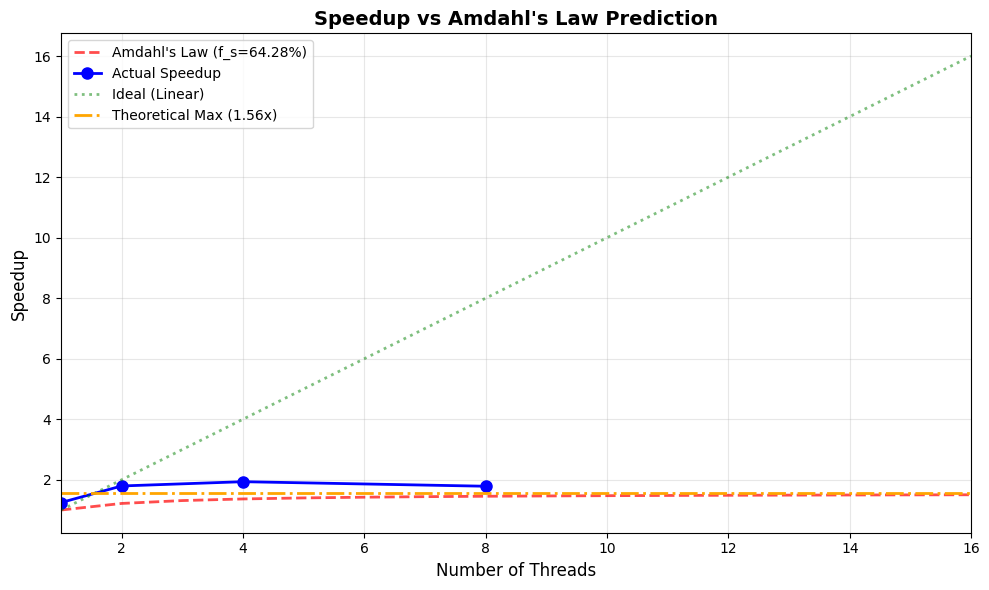


Theoretical maximum speedup: 1.56x


In [3]:
# Calculate serial fraction
T_serial_portion = serial_data['init_time']
T_total = serial_data['total_time']
f_serial = T_serial_portion / T_total  # Serial fraction
f_parallel = 1 - f_serial

print(f"Serial fraction: {f_serial:.2%}")
print(f"Parallel fraction: {f_parallel:.2%}")

# Amdahl's Law: Speedup = 1 / (f_serial + f_parallel/p)
threads_range = np.arange(1, 17)
amdahl_speedup = 1 / (f_serial + f_parallel / threads_range)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot theoretical Amdahl's Law
ax.plot(threads_range, amdahl_speedup, '--', label=f'Amdahl\'s Law (f_s={f_serial:.2%})', 
        linewidth=2, color='red', alpha=0.7)

# Plot actual measurements
ax.plot(parallel_data['threads'], parallel_data['speedup'], 'o-', label='Actual Speedup', 
        linewidth=2, markersize=8, color='blue')

# Plot ideal linear speedup
ax.plot(threads_range, threads_range, ':', label='Ideal (Linear)', 
        linewidth=2, color='green', alpha=0.5)

# Add theoretical limit
max_speedup = 1 / f_serial
ax.axhline(y=max_speedup, linestyle='-.', label=f'Theoretical Max ({max_speedup:.2f}x)', 
           color='orange', linewidth=2)

ax.set_xlabel('Number of Threads', fontsize=12)
ax.set_ylabel('Speedup', fontsize=12)
ax.set_title('Speedup vs Amdahl\'s Law Prediction', fontsize=14, weight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 16)

plt.tight_layout()
plt.savefig('ex2_amdahl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTheoretical maximum speedup: {max_speedup:.2f}x")

## 3. Time Breakdown (Stacked Bar Chart)

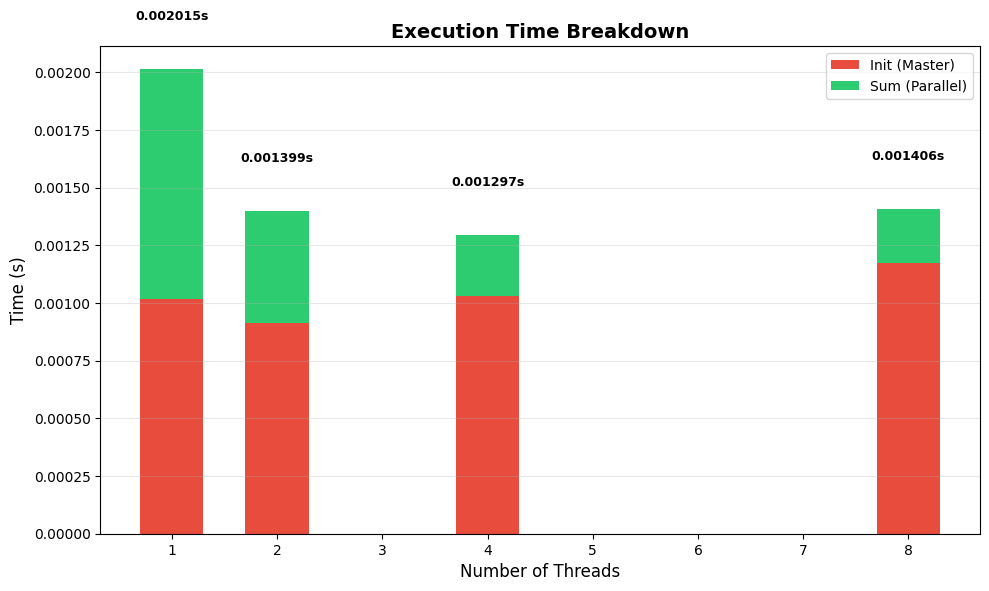

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

x = parallel_data['threads']
width = 0.6

# Stacked bars
p1 = ax.bar(x, parallel_data['init_time'], width, label='Init (Master)', color='#e74c3c')
p2 = ax.bar(x, parallel_data['sum_time'], width, bottom=parallel_data['init_time'],
            label='Sum (Parallel)', color='#2ecc71')

ax.set_xlabel('Number of Threads', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Execution Time Breakdown', fontsize=14, weight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add total time labels
for i, (thread, total) in enumerate(zip(parallel_data['threads'], parallel_data['total_time'])):
    ax.text(thread, total + 0.0002, f'{total:.6f}s', 
            ha='center', va='bottom', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('ex2_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Efficiency Analysis

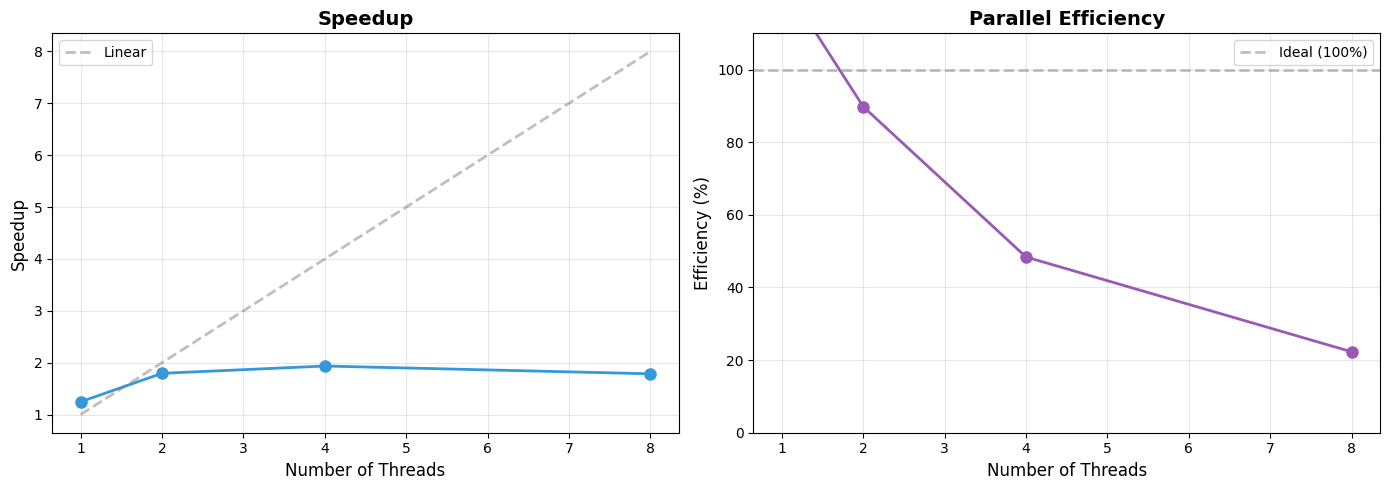

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Speedup
ax1.plot(parallel_data['threads'], parallel_data['speedup'], 'o-', linewidth=2, markersize=8, color='#3498db')
ax1.plot(parallel_data['threads'], parallel_data['threads'], '--', linewidth=2, color='gray', alpha=0.5, label='Linear')
ax1.set_xlabel('Number of Threads', fontsize=12)
ax1.set_ylabel('Speedup', fontsize=12)
ax1.set_title('Speedup', fontsize=14, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Efficiency
ax2.plot(parallel_data['threads'], parallel_data['efficiency'] * 100, 'o-', linewidth=2, markersize=8, color='#9b59b6')
ax2.axhline(y=100, linestyle='--', linewidth=2, color='gray', alpha=0.5, label='Ideal (100%)')
ax2.set_xlabel('Number of Threads', fontsize=12)
ax2.set_ylabel('Efficiency (%)', fontsize=12)
ax2.set_title('Parallel Efficiency', fontsize=14, weight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('ex2_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Takeaways

### Observations:
1. **Serial bottleneck**: Init limits speedup
2. **Amdahl's Law**: Matches theoretical prediction
3. **Diminishing returns**: Beyond 4 threads, little improvement

### Critical reminder:
**Always add explicit barrier after `master` if other threads need the result!**